In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("data/processed/clean.pkl")
print(df.shape)
print(df['label'].value_counts())

(25519, 7)
label
3    9680
2    5189
0    4294
4    3593
7    1193
6     866
1     555
5     149
Name: count, dtype: int64


In [3]:
class_counts = df['label'].value_counts().sort_index().values
print(class_counts)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum()
print(class_weights)

[4294  555 5189 9680 3593  149  866 1193]
tensor([0.0206, 0.1593, 0.0170, 0.0091, 0.0246, 0.5932, 0.1021, 0.0741])


In [4]:
import torch.nn.functional as F
class WaferDataset(Dataset):
    def __init__(self, dataframe):
        self.wafers = dataframe['waferMap'].values
        self.labels = dataframe['label'].values

    def __len__(self):
        # return the number of samples
        return len(self.wafers)

    def __getitem__(self, idx):
        wafer = self.wafers[idx]
        label = self.labels[idx]
        wafer = torch.tensor(wafer, dtype=torch.float32).unsqueeze(0)
        wafer = F.interpolate(wafer.unsqueeze(0), size=(45, 48), mode='nearest').squeeze(0)
        label = torch.tensor(label, dtype=torch.long)
        return wafer, label

In [5]:
dataset = WaferDataset(df)
print(f"Dataset size: {len(dataset)}")
wafer, label = dataset[0]
print(f"Wafer shape: {wafer.shape}")  # should be (1, H, W)
print(f"Label: {label}")
print(f"Wafer dtype: {wafer.dtype}")
print(f"Label dtype: {label.dtype}")

Dataset size: 25519
Wafer shape: torch.Size([1, 45, 48])
Label: 4
Wafer dtype: torch.float32
Label dtype: torch.int64


In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
torch.manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train size: 20415
Test size: 5104


In [7]:
from torch.utils.data import WeightedRandomSampler
train_labels = [dataset[i][1].item() for i in train_dataset.indices]

train_sample_weights = [class_weights[label] for label in train_labels]
train_sample_weights = torch.tensor(train_sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)

In [8]:
class WaferCNN(nn.Module):
    def __init__(self):
        super(WaferCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #Layer 1: 1 input channel, 32 output filters, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) #Layer 2: 32 input channels, 64 output filters, 3x3 kernel

        self.pool = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(8448, 128)
        self.fc2 = nn.Linear(128, 8)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
model = WaferCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for wafers, labels in train_loader:
        optimizer.zero_grad()#zero gradients
        outputs = model(wafers)#forward pass
        loss = criterion(outputs, labels)#calculate loss
        loss.backward()#backward pass
        optimizer.step()#nudge weights
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/10 - Loss: 0.6327
Epoch 2/10 - Loss: 0.3866
Epoch 3/10 - Loss: 0.3019
Epoch 4/10 - Loss: 0.2374
Epoch 5/10 - Loss: 0.1947
Epoch 6/10 - Loss: 0.1413
Epoch 7/10 - Loss: 0.1123
Epoch 8/10 - Loss: 0.0912
Epoch 9/10 - Loss: 0.0730
Epoch 10/10 - Loss: 0.0538


In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():  # don't compute gradients during evaluation
    for wafers, labels in test_loader:
        outputs = model(wafers)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 88.68%


In [11]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for wafers, labels in test_loader:
        outputs = model(wafers)
        predicted = torch.argmax(outputs, dim=1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

label_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']

print(classification_report(all_labels, all_preds, target_names=label_names))

              precision    recall  f1-score   support

      Center       0.94      0.96      0.95       849
       Donut       0.86      0.89      0.87       101
    Edge-Loc       0.82      0.92      0.87      1068
   Edge-Ring       0.99      0.95      0.97      1939
         Loc       0.82      0.66      0.73       733
   Near-full       0.93      0.97      0.95        29
      Random       0.95      0.88      0.92       161
     Scratch       0.46      0.64      0.53       224

    accuracy                           0.89      5104
   macro avg       0.85      0.86      0.85      5104
weighted avg       0.90      0.89      0.89      5104



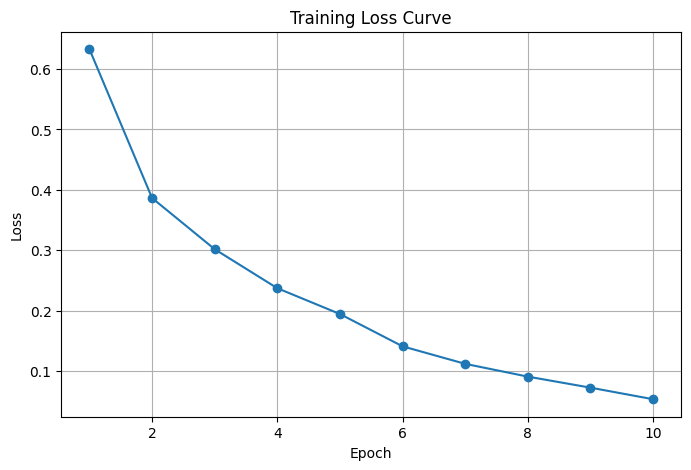

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig("data/training_loss.png")
plt.show()

In [13]:
torch.save(model.state_dict(), "models/wafer_cnn.pth")

RuntimeError: Parent directory models does not exist.